In [1]:
import numpy as np
import matplotlib.pyplot as plt

mu = 0.395
sigma = 0.226
S0 = 297
n_days = 252
n_paths = 1000
dt = 1/252

In [2]:
np.random.seed(42)
Z = np.random.standard_normal((n_paths, n_days))
print(Z.shape)

(1000, 252)


In [3]:
daily_log_returns = (mu - sigma**2/2) * dt + sigma * np.sqrt(dt) * Z
print(daily_log_returns.shape)

(1000, 252)


In [4]:
cumulative = np.cumsum(daily_log_returns, axis=1) #operate across columns
price_paths = S0 * np.exp(cumulative)
print(price_paths.shape)

(1000, 252)


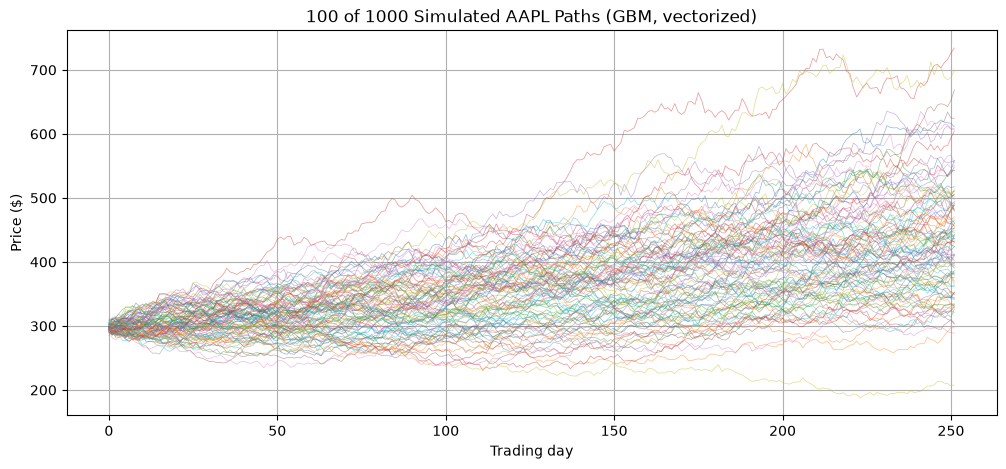

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(price_paths[:100].T, linewidth=0.5, alpha=0.5) #firs 100 rows; .T transpose; alpha=0.5 lines semi transparent
plt.title("100 of 1000 Simulated AAPL Paths (GBM, vectorized)")
plt.xlabel("Trading day")
plt.ylabel("Price ($)")
plt.grid(True)
plt.show()

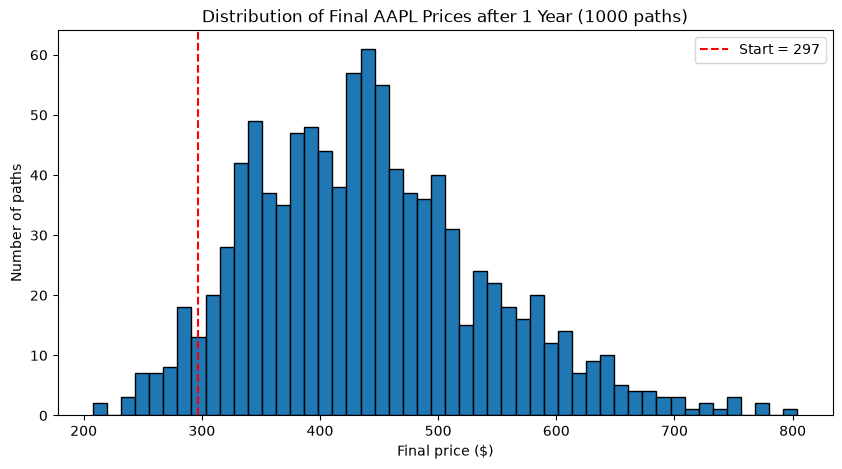

In [8]:
final_prices = price_paths[:, -1] #ending price of every path

plt.figure(figsize=(10, 5))
plt.hist(final_prices, bins=50, edgecolor="black")
plt.title("Distribution of Final AAPL Prices after 1 Year (1000 paths)")
plt.xlabel("Final price ($)")
plt.ylabel("Number of paths")
plt.axvline(S0, color="red", linestyle="--", label=f"Start = {S0}") # text in legend, vertical line
plt.legend()
plt.legend()
plt.show()